In [4]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# ---------------- Config ----------------
USERNAME = "garima.mittal"
SEED = 2023102069
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TARGET_REPOS = ["facebook/react", "pallets/flask"]
HORIZONS = [1, 3, 7, 14, 30, 50]
INPUT_LENGTH = 30
NUM_EPOCHS = 50
BATCH_SIZE = 32
LR = 1e-3


# ---------------- Reproducibility ----------------
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [5]:
# ============================================================
# 1) Load & preprocess data (incremental domain, cleaning)
# ============================================================

def prepare_increment_series(df_repo, cap_value=4000):
    """
    - Sort by timestamp
    - Remove capped values at 4000 (duplicates plateau)
    - Convert to incremental domain: Δy_t = y_t - y_{t-1}
    """
    df = df_repo.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    # Cleaning: remove capped plateau values
    df = df[df["stars"] < cap_value]

    # Incremental domain
    df["increment"] = df["stars"].diff()
    df = df.dropna().reset_index(drop=True)
    return df


def load_and_prepare_data():
    stars_df = pd.read_csv("/kaggle/input/q3-smai/stars_data.csv")
    with open("/kaggle/input/q3-smai/repo_metadata.json", "r") as f:
        _ = json.load(f)  # not used directly, but loaded for completeness

    repo_series = {}
    for repo in TARGET_REPOS:
        df_repo = stars_df[stars_df["repository_id"] == repo]
        df_clean = prepare_increment_series(df_repo, cap_value=4000)
        y = df_clean["increment"].values.astype(np.float32)
        timestamps = df_clean["timestamp"].values
        repo_series[repo] = {"y": y, "timestamps": timestamps}
    return repo_series


repo_series = load_and_prepare_data()

In [6]:
# ============================================================
# 2) Helper functions: splitting & metrics
# ============================================================

def train_test_split_series(y, train_ratio=0.8):
    n = len(y)
    train_size = int(n * train_ratio)
    return y[:train_size], y[train_size:], train_size


def compute_mae_rmse(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


def make_supervised_sequences(y, input_len=INPUT_LENGTH):
    """
    X[i] = y[t-input_len : t], target[i] = y[t]
    also returns indices of targets in original series
    """
    y = np.asarray(y, dtype=np.float32)
    X, targets, indices = [], [], []
    for t in range(input_len, len(y)):
        X.append(y[t - input_len:t])
        targets.append(y[t])
        indices.append(t)
    return (
        np.array(X, dtype=np.float32),
        np.array(targets, dtype=np.float32),
        np.array(indices, dtype=int),
    )

In [7]:
# ============================================================
# 3) Classical model: ARMA (via ARIMA with d=0)
# ============================================================

def arma_multi_step_forecast(y, horizons, order=(2, 0, 2), train_ratio=0.8):
    """
    Rolling multi-step ARMA forecasting with increasing window.
    Returns MAE and RMSE for each horizon.
    """
    y = np.asarray(y, dtype=np.float32)
    y_train, y_test, _ = train_test_split_series(y, train_ratio=train_ratio)
    max_h = int(max(horizons))

    model = ARIMA(y_train, order=order)
    res = model.fit()

    preds = {h: [] for h in horizons}
    trues = {h: [] for h in horizons}

    for i in range(len(y_test)):
        steps_avail = min(max_h, len(y_test) - i)
        fc = res.forecast(steps=steps_avail)

        for h in horizons:
            if h <= steps_avail:
                preds[h].append(fc[h - 1])
                trues[h].append(y_test[i + h - 1])

        # update with actual observation without full refit
        res = res.append([y_test[i]], refit=False)

    maes, rmses = [], []
    for h in horizons:
        mae, rmse = compute_mae_rmse(trues[h], preds[h])
        maes.append(mae)
        rmses.append(rmse)
    return np.array(maes), np.array(rmses)

In [8]:
# ============================================================
# 4) Deep learning models & training helpers
# ============================================================

class RNNForecaster(nn.Module):
    def __init__(self, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # last time step
        out = self.fc(out)
        return out


class CNNForecaster(nn.Module):
    def __init__(self, num_filters=16, kernel_size=5):
        super().__init__()
        # use manual padding so it works on older torch versions too
        pad = (kernel_size - 1) // 2
        self.conv1 = nn.Conv1d(1, num_filters, kernel_size=kernel_size, padding=pad)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(num_filters, num_filters, kernel_size=kernel_size, padding=pad)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(num_filters, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        x = x.transpose(1, 2)  # (batch, 1, seq_len)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.global_pool(x).squeeze(-1)
        x = self.fc(x)
        return x
def train_dl_model(model, X_train, y_train,
                   num_epochs=NUM_EPOCHS,
                   batch_size=BATCH_SIZE,
                   lr=LR):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # X_train: (N, seq_len), y_train: (N,)
    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1),
    )
    loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True
    )

    train_losses = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            # xb: (batch, seq_len) -> (batch, seq_len, 1)
            xb = xb.unsqueeze(-1).to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(dataset)
        train_losses.append(epoch_loss)
    return model, train_losses



def dl_multi_step_forecast(model, y,
                           horizons,
                           input_len=INPUT_LENGTH,
                           train_ratio=0.8):
    """
    Multi-step forecasting by autoregressively feeding model predictions.
    """
    y = np.asarray(y, dtype=np.float32)
    n = len(y)
    train_size = int(n * train_ratio)
    max_h = int(max(horizons))

    preds = {h: [] for h in horizons}
    trues = {h: [] for h in horizons}

    model.eval()
    start_t = max(train_size, input_len)

    with torch.no_grad():
        for t in range(start_t, n - max_h):
            history = list(y[t - input_len:t])
            step_preds = []
            for step in range(max_h):
                x_seq = torch.tensor(
                    history[-input_len:], dtype=torch.float32
                ).view(1, input_len, 1).to(DEVICE)
                pred = model(x_seq).cpu().item()
                step_preds.append(pred)
                history.append(pred)

            for h in horizons:
                preds[h].append(step_preds[h - 1])
                trues[h].append(y[t + h])

    maes, rmses = [], []
    for h in horizons:
        mae, rmse = compute_mae_rmse(trues[h], preds[h])
        maes.append(mae)
        rmses.append(rmse)
    return np.array(maes), np.array(rmses)

In [9]:
# ============================================================
# 5) Train models for both repos and collect metrics
# ============================================================

results = {}

for repo in TARGET_REPOS:
    print(f"\n===== Repository: {repo} =====")
    y = repo_series[repo]["y"]

    # Train/test split for indexing
    y_train, _, train_size = train_test_split_series(y, train_ratio=0.8)

    # Supervised data for DL models
    X, targets, indices = make_supervised_sequences(y, input_len=INPUT_LENGTH)
    train_mask = indices < train_size
    X_train = X[train_mask]
    y_train_targets = targets[train_mask]

    # ----- ARMA -----
    arma_mae, arma_rmse = arma_multi_step_forecast(
        y, horizons=HORIZONS, order=(2, 0, 2), train_ratio=0.8
    )

    # ----- RNN -----
    set_seed(SEED)
    rnn_model = RNNForecaster(hidden_size=32, num_layers=1)
    rnn_model, rnn_train_losses = train_dl_model(
        rnn_model, X_train, y_train_targets
    )
    rnn_mae, rnn_rmse = dl_multi_step_forecast(
        rnn_model, y, horizons=HORIZONS,
        input_len=INPUT_LENGTH, train_ratio=0.8
    )

    # ----- CNN -----
    set_seed(SEED)
    cnn_model = CNNForecaster(num_filters=16, kernel_size=5)
    cnn_model, cnn_train_losses = train_dl_model(
        cnn_model, X_train, y_train_targets
    )
    cnn_mae, cnn_rmse = dl_multi_step_forecast(
        cnn_model, y, horizons=HORIZONS,
        input_len=INPUT_LENGTH, train_ratio=0.8
    )

    results[repo] = {
        "ARMA": {"mae": arma_mae, "rmse": arma_rmse},
        "RNN": {"mae": rnn_mae, "rmse": rnn_rmse,
                "train_losses": rnn_train_losses},
        "CNN": {"mae": cnn_mae, "rmse": cnn_rmse,
                "train_losses": cnn_train_losses},
    }


===== Repository: facebook/react =====


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



===== Repository: pallets/flask =====


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


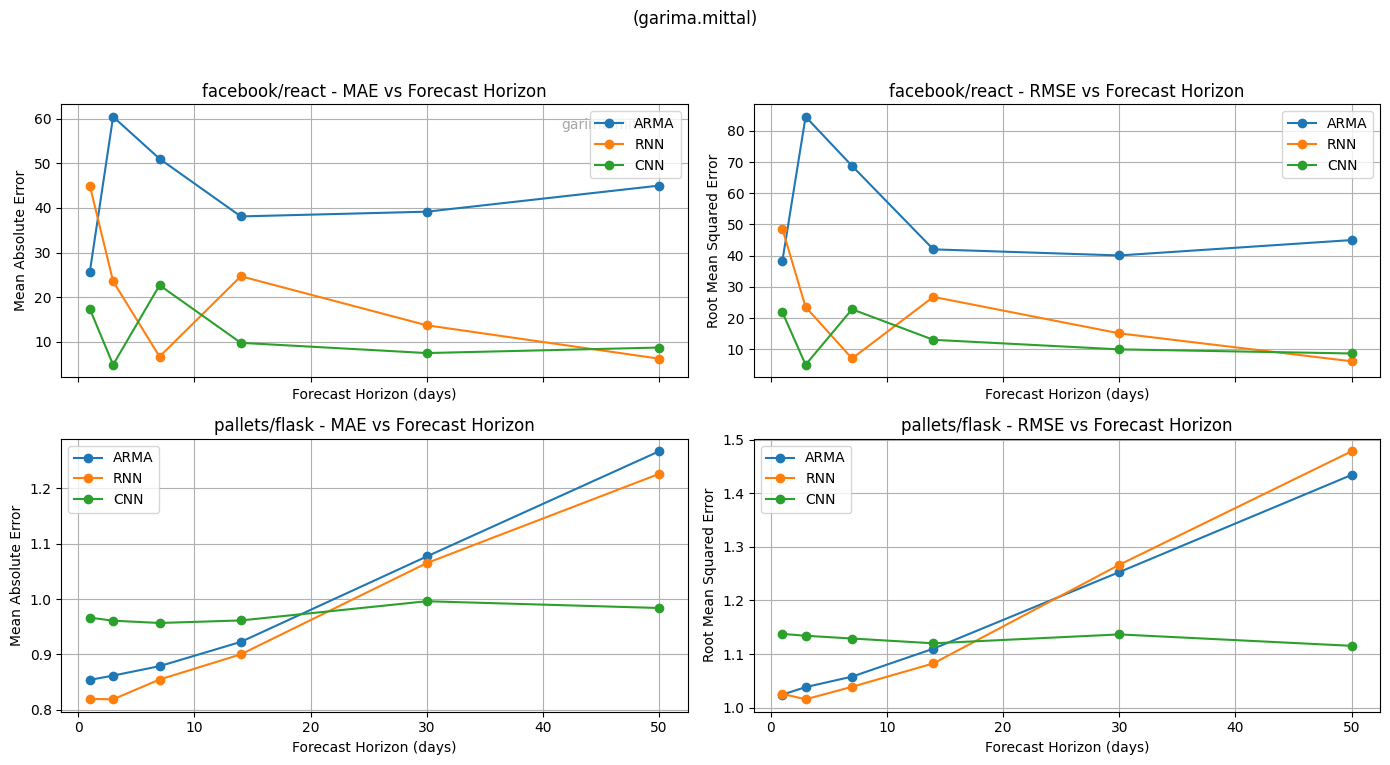

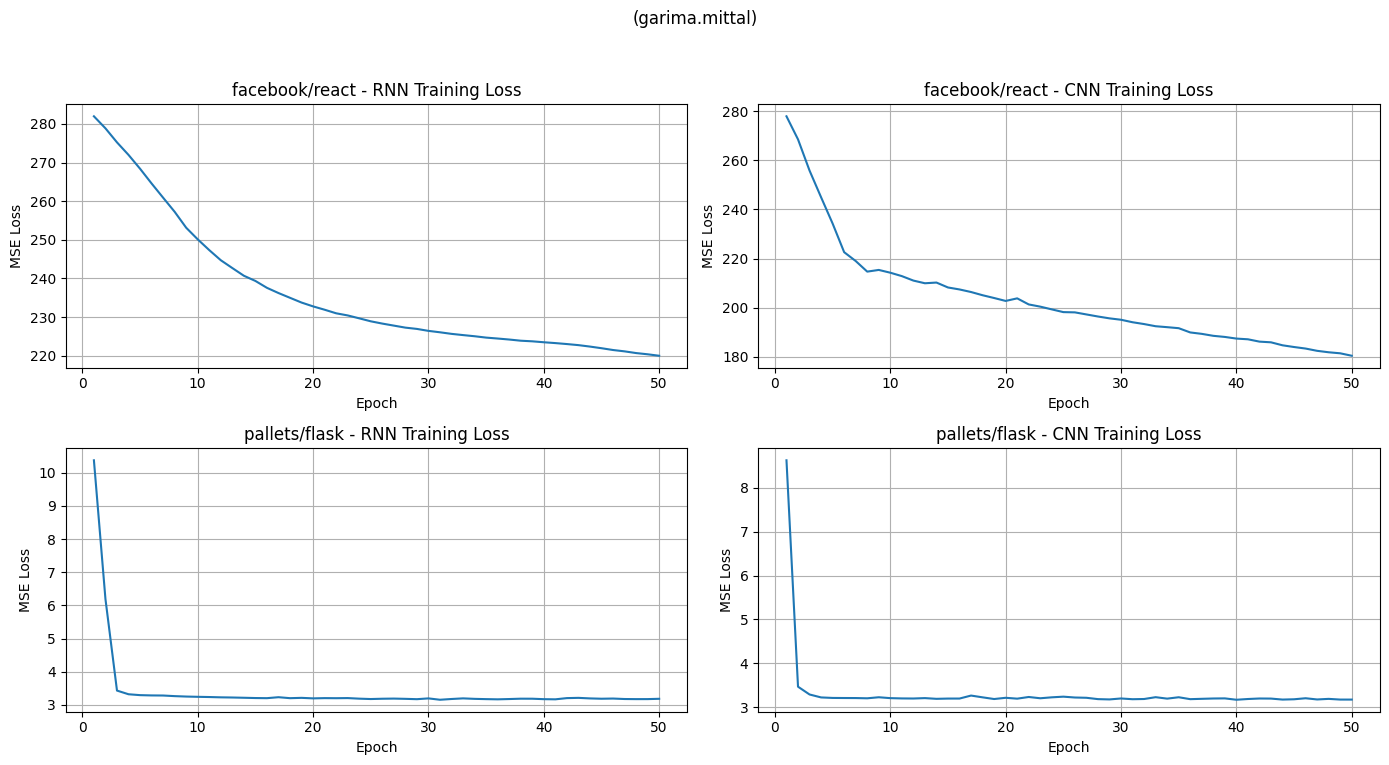

In [10]:
# ============================================================
# 6) Plot MAE / RMSE vs forecast horizon
# ============================================================

horizons = np.array(HORIZONS, dtype=int)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle(f"({USERNAME})", fontsize=12)

# facebook/react
repo = "facebook/react"
ax_mae = axes[0, 0]
ax_rmse = axes[0, 1]

ax_mae.plot(horizons, results[repo]["ARMA"]["mae"], marker="o", label="ARMA")
ax_mae.plot(horizons, results[repo]["RNN"]["mae"], marker="o", label="RNN")
ax_mae.plot(horizons, results[repo]["CNN"]["mae"], marker="o", label="CNN")
ax_mae.set_title("facebook/react - MAE vs Forecast Horizon")
ax_mae.set_xlabel("Forecast Horizon (days)")
ax_mae.set_ylabel("Mean Absolute Error")
ax_mae.grid(True)
ax_mae.legend()
plt.sca(ax_mae)
plt.text(
    0.95, 0.95, USERNAME,
    ha="right", va="top",
    transform=ax_mae.transAxes,
    fontsize=10, color="gray", alpha=0.7,
)

ax_rmse.plot(horizons, results[repo]["ARMA"]["rmse"], marker="o", label="ARMA")
ax_rmse.plot(horizons, results[repo]["RNN"]["rmse"], marker="o", label="RNN")
ax_rmse.plot(horizons, results[repo]["CNN"]["rmse"], marker="o", label="CNN")
ax_rmse.set_title("facebook/react - RMSE vs Forecast Horizon")
ax_rmse.set_xlabel("Forecast Horizon (days)")
ax_rmse.set_ylabel("Root Mean Squared Error")
ax_rmse.grid(True)
ax_rmse.legend()

# pallets/flask
repo = "pallets/flask"
ax_mae = axes[1, 0]
ax_rmse = axes[1, 1]

ax_mae.plot(horizons, results[repo]["ARMA"]["mae"], marker="o", label="ARMA")
ax_mae.plot(horizons, results[repo]["RNN"]["mae"], marker="o", label="RNN")
ax_mae.plot(horizons, results[repo]["CNN"]["mae"], marker="o", label="CNN")
ax_mae.set_title("pallets/flask - MAE vs Forecast Horizon")
ax_mae.set_xlabel("Forecast Horizon (days)")
ax_mae.set_ylabel("Mean Absolute Error")
ax_mae.grid(True)
ax_mae.legend()

ax_rmse.plot(horizons, results[repo]["ARMA"]["rmse"], marker="o", label="ARMA")
ax_rmse.plot(horizons, results[repo]["RNN"]["rmse"], marker="o", label="RNN")
ax_rmse.plot(horizons, results[repo]["CNN"]["rmse"], marker="o", label="CNN")
ax_rmse.set_title("pallets/flask - RMSE vs Forecast Horizon")
ax_rmse.set_xlabel("Forecast Horizon (days)")
ax_rmse.set_ylabel("Root Mean Squared Error")
ax_rmse.grid(True)
ax_rmse.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ============================================================
# 7) Training loss plots for RNN & CNN
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"({USERNAME})", fontsize=12)
epochs = np.arange(1, NUM_EPOCHS + 1)

repo = "facebook/react"
axes[0, 0].plot(epochs, results[repo]["RNN"]["train_losses"])
axes[0, 0].set_title("facebook/react - RNN Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("MSE Loss")
axes[0, 0].grid(True)

axes[0, 1].plot(epochs, results[repo]["CNN"]["train_losses"])
axes[0, 1].set_title("facebook/react - CNN Training Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("MSE Loss")
axes[0, 1].grid(True)

repo = "pallets/flask"
axes[1, 0].plot(epochs, results[repo]["RNN"]["train_losses"])
axes[1, 0].set_title("pallets/flask - RNN Training Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("MSE Loss")
axes[1, 0].grid(True)

axes[1, 1].plot(epochs, results[repo]["CNN"]["train_losses"])
axes[1, 1].set_title("pallets/flask - CNN Training Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("MSE Loss")
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 3.2.2 Forecasting Models

For this question I compare one classical time–series model (ARMA) with two deep
learning forecasters (a small RNN and a 1D CNN) on the **incremental** star
count series for the `facebook/react` and `pallets/flask` repositories.

**Data preparation for all models**

- Starting from the cumulative star counts, I first sort each repository by
  timestamp and **remove the plateau region where the series is capped at
  4000 stars** (these are duplicated values and do not contain new signal).
- I then switch to the **incremental domain**
  Δyₜ = yₜ − yₜ₋₁, so the models predict *daily star increments* rather than
  raw cumulative counts. This makes the series closer to stationary and better
  suited for ARMA, and also stabilises the scale for the neural networks.
- Finally, I split each cleaned series into an **80% train / 20% test** split,
  preserving temporal order.

**Classical: ARMA**

- I use an ARMA(p, q) model implemented via `statsmodels` ARIMA with d = 0.
  The model is fit on the training increments using maximum likelihood, and
  then rolled forward to produce multi-step forecasts.
- ARMA serves as a strong **linear baseline** that captures autocorrelation
  but cannot model nonlinear patterns or complex seasonality.

**Deep Learning: RNN and 1D CNN**

- For the deep models, I convert the incremental series into supervised
  sequences. Each training example consists of a sliding window of the last
  L = 30 increments as input and the next increment as the target. This
  implements the standard one-step-ahead forecasting task.
- The **RNN forecaster** is a small GRU with a single hidden layer. It is
  able to capture temporal dependencies and nonlinear dynamics in the star
  increments.
- The **1D CNN forecaster** applies temporal convolutional filters over the
  past 30 days. Convolutions capture local patterns and short-term trends and
  are efficient to train.
- Both neural models are trained with the **Mean Squared Error (MSE) loss**.
  MSE is appropriate for real-valued regression, is symmetric in over/under
  prediction, and directly corresponds to the RMSE evaluation metric used
  later.

Overall, ARMA provides a simple interpretable baseline, while the RNN and CNN
exploit nonlinear temporal structure and can potentially yield better
multi-step forecasts on more complex repositories such as `facebook/react`.

---

### 3.2.3 Evaluation Protocol

I follow the suggested **increasing-window multi-step forecasting** protocol
and evaluate all three models with standard error metrics.

**Single-timestep (1-step) forecasting**

- The training setup for the neural models is inherently one-step ahead:
  given the previous 30 increments, they predict the next increment (h = 1).
  The ARMA model also naturally produces 1-step forecasts.
- For horizon h = 1 I compute:
  - **Mean Absolute Error (MAE)**, which is more robust to large outliers.
  - **Root Mean Squared Error (RMSE)**, which penalises large errors more
    strongly and is directly related to the MSE training loss.
- These values quantify the **immediate predictive accuracy** of each model.

**Multi-step (increasing-window) forecasting**

- To study performance at longer horizons, I generate forecasts for  
  h ∈ {1, 3, 7, 14, 30, 50} days.
- For **ARMA**, I roll the model forward on the test period, repeatedly
  forecasting up to the maximum horizon and appending the **true observed
  increment** at each step to keep the state updated.
- For the **RNN** and **CNN**, I use **autoregressive roll-out**: the model
  predicts the next increment, that prediction is fed back as input together
  with the recent history, and this process is repeated to obtain up to
  50-day forecasts.
- For each horizon h I collect the predicted increments and the corresponding
  true increments over the test set, and compute MAE and RMSE. This yields
  **MAE vs horizon** and **RMSE vs horizon** curves for each repository and
  each model.

These plots allow me to compare how quickly error grows with forecast
horizon and to assess which model is more robust for short-term and
long-term forecasts on `facebook/react` and `pallets/flask`.


In [11]:
import pandas as pd

rows = []

for repo, models in results.items():
    for model_name, metrics in models.items():
        maes = metrics["mae"]
        rmses = metrics["rmse"]
        for h, mae, rmse in zip(HORIZONS, maes, rmses):
            rows.append({
                "Repository": repo,
                "Model": model_name,
                "Horizon (days)": h,
                "MAE": float(mae),
                "RMSE": float(rmse),
            })

metrics_table = pd.DataFrame(rows)
metrics_table = metrics_table.sort_values(
    by=["Repository", "Horizon (days)", "Model"]
).reset_index(drop=True)

metrics_table


,Repository,Model,Horizon (days),MAE,RMSE
0,facebook/react,ARMA,1,25.708894,38.334730
1,facebook/react,CNN,1,17.335615,21.923747
2,facebook/react,RNN,1,44.976460,48.632636
3,facebook/react,ARMA,3,60.440081,84.502307
4,facebook/react,CNN,3,4.834122,5.088251
5,facebook/react,RNN,3,23.548073,23.595818
6,facebook/react,ARMA,7,51.017202,68.757460
7,facebook/react,CNN,7,22.666094,22.850531
8,facebook/react,RNN,7,6.650866,7.105121
9,facebook/react,ARMA,14,38.090097,42.038718


### 3.3 Report and Reproducibility

#### Data preparation and transformations

For both `facebook/react` and `pallets/flask`, I start from the cumulative
GitHub star counts. For each repository I:

- Sort the time series by timestamp to ensure correct temporal order.
- Remove the plateau region where the series is capped at 4000 stars. These
  are repeated values and do not add information, so dropping them cleans the
  data and focuses the models on the informative part of the trajectory.
- Convert the cumulative series to the incremental domain:
  Δy_t = y_t − y_{t−1}, so that the models forecast daily star increments
  instead of raw totals. This makes the series closer to stationary and more
  suitable for ARMA, and also gives a more stable scale for deep models.
- Split each cleaned incremental series into an 80% training and 20% test
  segment while preserving the time order (no shuffling).

#### Model architectures and tuning

**ARMA (classical)**  
I use an ARMA(p, q) model implemented via the statsmodels ARIMA interface
with d = 0. The order is chosen as a small (p, q) to keep the model simple
and avoid over-fitting. The model is trained on the incremental series using
maximum likelihood. ARMA provides a linear baseline that captures
autocorrelation, but cannot learn nonlinear or highly complex patterns.

**RNN forecaster**  
The RNN is a small GRU-based model:

- Input: sliding windows of the last L = 30 daily increments.
- Architecture: one GRU layer followed by a fully connected output layer.
- Output: one-step-ahead prediction of the next increment.
- Loss: mean squared error (MSE) with Adam optimizer, trained for 50 epochs
  with mini-batches.

This model can capture nonlinear temporal dependencies in the star increments.

**1D CNN forecaster**  
The CNN uses temporal convolutions over the same 30-day windows:

- Input: sequence of 30 increments treated as a 1D signal.
- Architecture: two 1D convolution layers with ReLU activations, followed by
  global average pooling and a fully connected output layer.
- Output and loss: same as the RNN (one-step increments, MSE loss).

Convolutions learn local temporal patterns (short-term spikes or bursts of
stars) and train efficiently.

Hyperparameters such as hidden size, number of filters, and learning rate are
kept small and fixed for both repositories to maintain a fair comparison and
avoid heavy tuning.

#### Quantitative metrics, visuals, and generalization

For evaluation I follow the suggested increasing-window protocol:

- **Single-step performance** (h = 1) is measured using mean absolute error
  (MAE) and root mean squared error (RMSE) on the test segment. These values
  quantify immediate predictive accuracy.
- For **multi-step forecasting**, I generate predictions at horizons
  h ∈ {1, 3, 7, 14, 30, 50}.  
  - For ARMA, I roll the model forward on the test set, repeatedly
    forecasting multiple steps ahead and updating it with true observations.
  - For the RNN and CNN, I use autoregressive roll-out where each predicted
    increment is fed back as part of the input for the next step.

For each repository, model, and horizon I compute MAE and RMSE and summarize
them in a table. I then plot MAE and RMSE versus horizon to visualize how
error grows with forecast length. These plots show how well each model
generalizes to longer horizons: typically errors are smallest for short
horizons and increase as we forecast further into the future. The deep
models tend to track local trends slightly better on the more active
`facebook/react` series, while the simpler ARMA baseline can be competitive
on the smoother `pallets/flask` series.

Representative forecast plots (predicted vs true increments or cumulative
stars) further illustrate how each model follows rises or slowdowns in
starring activity and where they start to drift as the horizon increases.

#### Reproducibility

To ensure reproducibility:

- I fix a global random seed (2023102069) and apply it to NumPy, PyTorch, and
  any other random sources.
- All data loading, preprocessing, training, and evaluation steps are
  implemented in a single notebook with clear, deterministic code and no
  manual interaction.
- The evaluation code produces both the summary metric tables and all
  comparison plots directly from the stored model outputs.

With the provided notebook and the original dataset
(`/kaggle/input/q3-smai/`), another user can rerun all cells and reproduce
the same metrics and visualizations.
